In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = pd.read_csv('/content/car_data.csv')

In [3]:
data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [4]:
data.shape

(301, 9)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
data.isna().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [7]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [8]:
print('\nFuel Type:')
print(data['Fuel_Type'].value_counts())
print('\nSeller Type:')
print(data['Seller_Type'].value_counts())
print('\nTransmission:')
print(data['Transmission'].value_counts())
print('\nOwner:')
print(data['Owner'].value_counts())


Fuel Type:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64

Seller Type:
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64

Transmission:
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64

Owner:
Owner
0    290
1     10
3      1
Name: count, dtype: int64


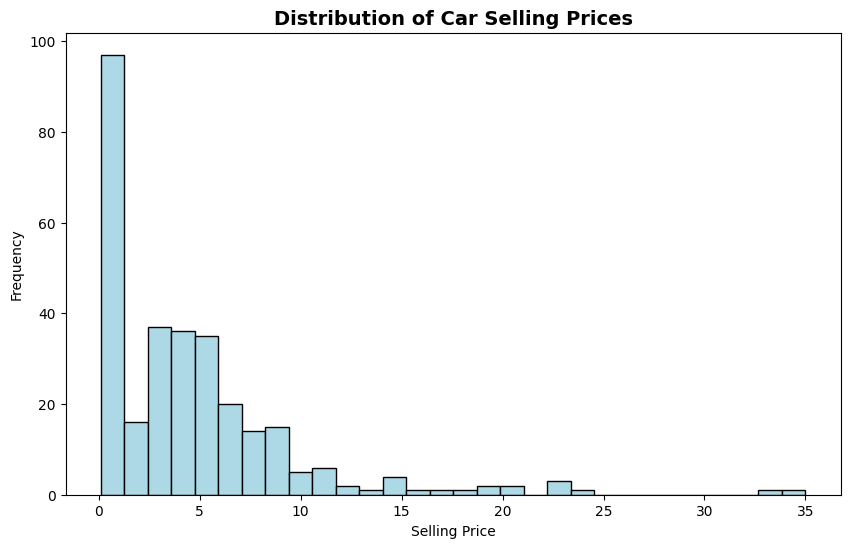

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(data['Selling_Price'], bins=30, color='lightblue', edgecolor='black')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.title('Distribution of Car Selling Prices', fontsize=14, fontweight='bold')
plt.show()

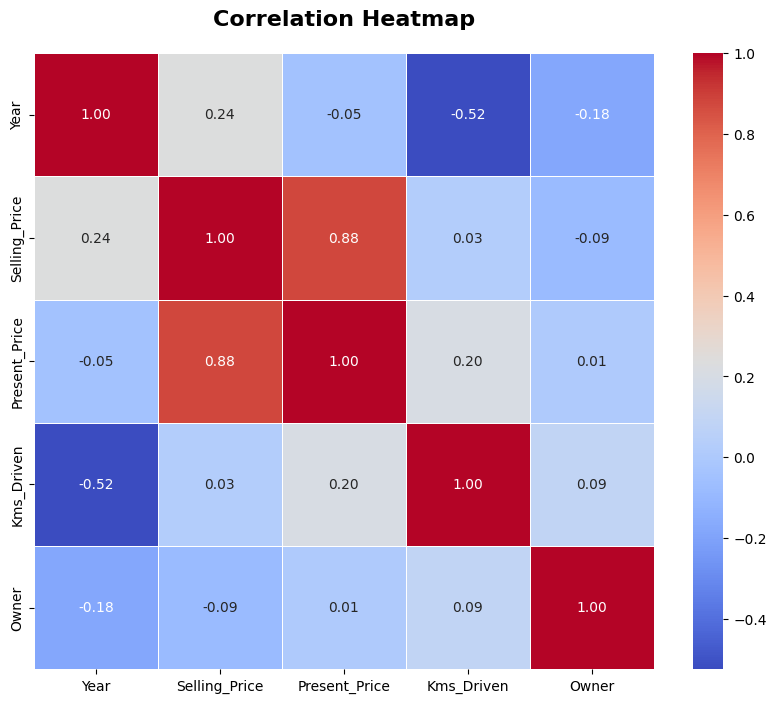

In [10]:
plt.figure(figsize=(10, 8))
numeric_cols = data.select_dtypes(include=['int', 'float64'])
correlation = numeric_cols.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.show()

/tmp/ipykernel_10741/2604110452.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Fuel_Type', y='Selling_Price', data=data, palette="Set2")


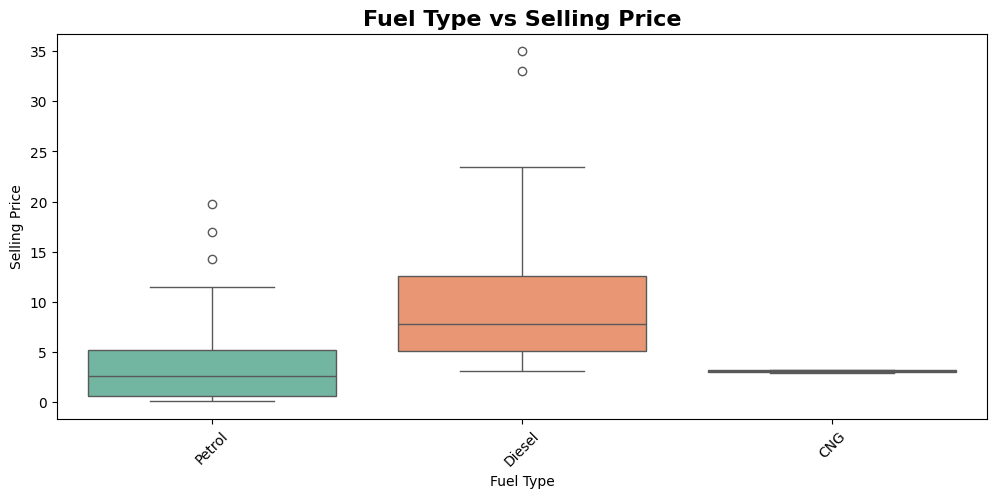

In [11]:
# Fuel type vs Selling Price
plt.figure(figsize=(12, 5))
sns.boxplot(x='Fuel_Type', y='Selling_Price', data=data, palette="Set2")
plt.title('Fuel Type vs Selling Price', fontsize=16, fontweight='bold')
plt.xlabel('Fuel Type')
plt.ylabel('Selling Price')
plt.xticks(rotation=45)
plt.show()

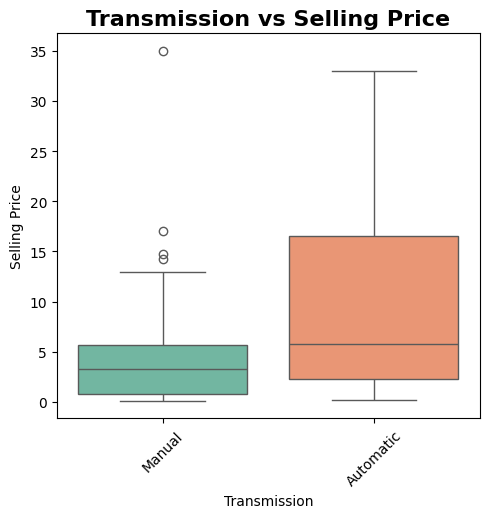

In [12]:
# Transmission vs Selling Price
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 2)
sns.boxplot(x='Transmission', y='Selling_Price', data=data, palette="Set2", hue='Transmission', legend=False)
plt.title('Transmission vs Selling Price', fontsize=16, fontweight='bold')
plt.xlabel('Transmission')
plt.ylabel('Selling Price')
plt.xticks(rotation=45)
plt.show()

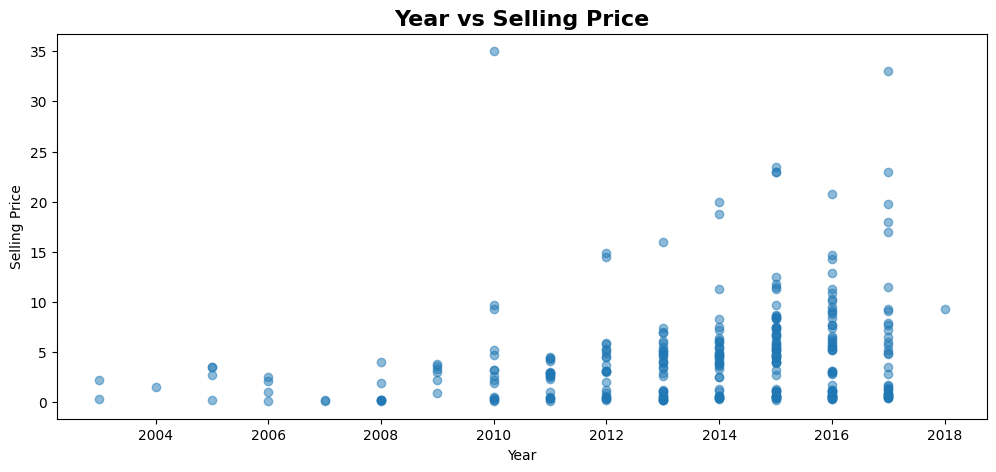

In [13]:
# Year vs Selling Price

plt.figure(figsize=(12, 5))
plt.scatter(data['Year'], data['Selling_Price'], alpha=0.5)
plt .title('Year vs Selling Price', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Selling Price')
plt.show()

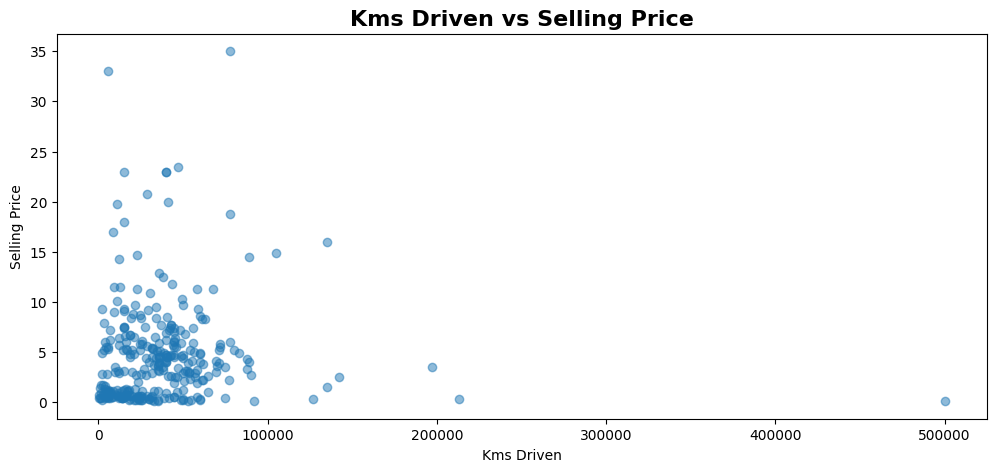

In [14]:
# kms driven vs Selling Price
plt.figure(figsize=(12, 5))
plt.scatter(data['Kms_Driven'], data['Selling_Price'], alpha=0.5)
plt.title('Kms Driven vs Selling Price', fontsize=16, fontweight='bold')
plt.xlabel('Kms Driven')
plt.ylabel('Selling Price')
plt.show()

In [15]:
# Encoding

data.replace({"Fuel_Type": {'Petrol': 0, 'Diesel': 1, 'CNG': 2}}, inplace=True)
data.replace({"Seller_Type": {'Dealer': 0, 'Individual': 1}}, inplace=True)
data.replace({"Transmission": {'Manual': 0, 'Automatic': 1}}, inplace=True)

print("Encoded Data")
data

Encoded Data


/tmp/ipykernel_10741/1338205561.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"Fuel_Type": {'Petrol': 0, 'Diesel': 1, 'CNG': 2}}, inplace=True)
/tmp/ipykernel_10741/1338205561.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"Seller_Type": {'Dealer': 0, 'Individual': 1}}, inplace=True)
/tmp/ipykernel_10741/1338205561.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,1,0,0,0
297,brio,2015,4.00,5.90,60000,0,0,0,0
298,city,2009,3.35,11.00,87934,0,0,0,0
299,city,2017,11.50,12.50,9000,1,0,0,0


In [16]:
X = data.drop(['Car_Name', 'Selling_Price'], axis=1)
y = data['Selling_Price']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
# Model 1: Linear Regression

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [19]:
lr_pred = lr_model.predict(X_test)

print("Linear Regression")
print("\nTraining Data")
print("R2 Score:", r2_score(y_train, lr_model.predict(X_train)))
print("Mean Absolute Error:", mean_absolute_error(y_train, lr_model.predict(X_train)))
print("Mean Squared Error:", mean_squared_error(y_train, lr_model.predict(X_train)))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_train, lr_model.predict(X_train))))

print("\nTesting Data")
print("R2 Score:", r2_score(y_test, lr_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, lr_pred))
print("Mean Squared Error:", mean_squared_error(y_test, lr_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, lr_pred)))

Linear Regression

Training Data
R2 Score: 0.883979349675079
Mean Absolute Error: 1.1761077496254098
Mean Squared Error: 3.0672445262788073
Root Mean Squared Error: 1.7513550543161736

Testing Data
R2 Score: 0.8468053957655798
Mean Absolute Error: 1.2217615462334326
Mean Squared Error: 3.5289272538944014
Root Mean Squared Error: 1.87854391854287


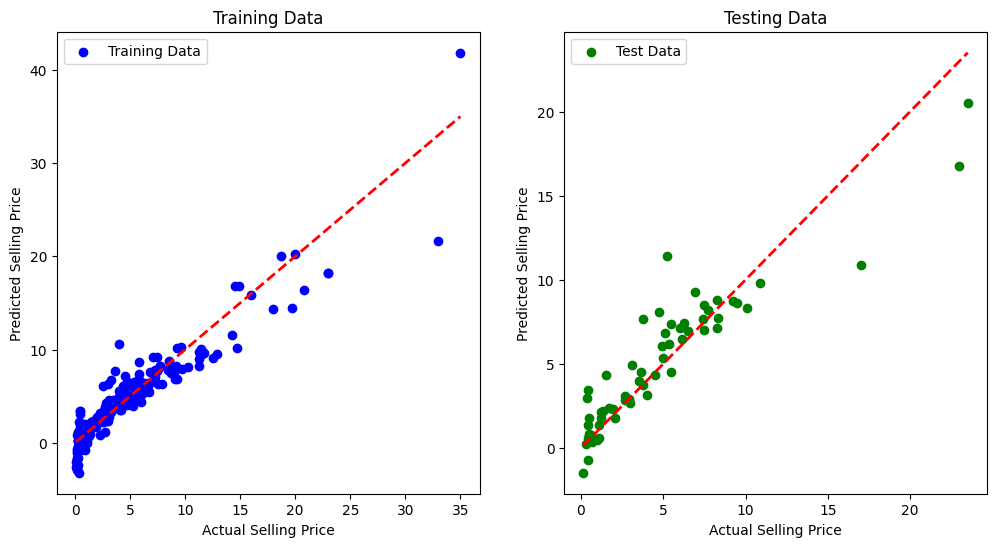

In [20]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

axes[0].scatter(y_train, lr_model.predict(X_train), color='blue', label='Training Data')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Selling Price')
axes[0].set_ylabel('Predicted Selling Price')
axes[0].set_title('Training Data')
axes[0].legend()

axes[1].scatter(y_test, lr_model.predict(X_test), color='green', label='Test Data')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Selling Price')
axes[1].set_ylabel('Predicted Selling Price')
axes[1].set_title('Testing Data')
axes[1].legend()

plt.show()

In [21]:
# Model 2: Lasso Regression

lasso_model = Lasso()
lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

print("Lasso Regression")
print("\nTraining Data")
print("R2 Score:", r2_score(y_train, lasso_model.predict(X_train)))
print("Mean Absolute Error:", mean_absolute_error(y_train, lasso_model.predict(X_train)))
print("Mean Squared Error:", mean_squared_error(y_train, lasso_model.predict(X_train)))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_train, lasso_model.predict(X_train))))

print("\nTesting Data")
print("R2 Score:", r2_score(y_test, lasso_pred))
print("Mean Absolute Error:", mean_squared_error(y_test, lasso_pred))
print("Mean Squared Error:", mean_squared_error(y_test, lasso_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, lasso_pred)))

Lasso Regression

Training Data
R2 Score: 0.848030286813716
Mean Absolute Error: 1.2231110358007187
Mean Squared Error: 4.017631944187324
Root Mean Squared Error: 2.004403139138263

Testing Data
R2 Score: 0.798551246128469
Mean Absolute Error: 4.6404897963148
Mean Squared Error: 4.6404897963148
Root Mean Squared Error: 2.1541796109690576


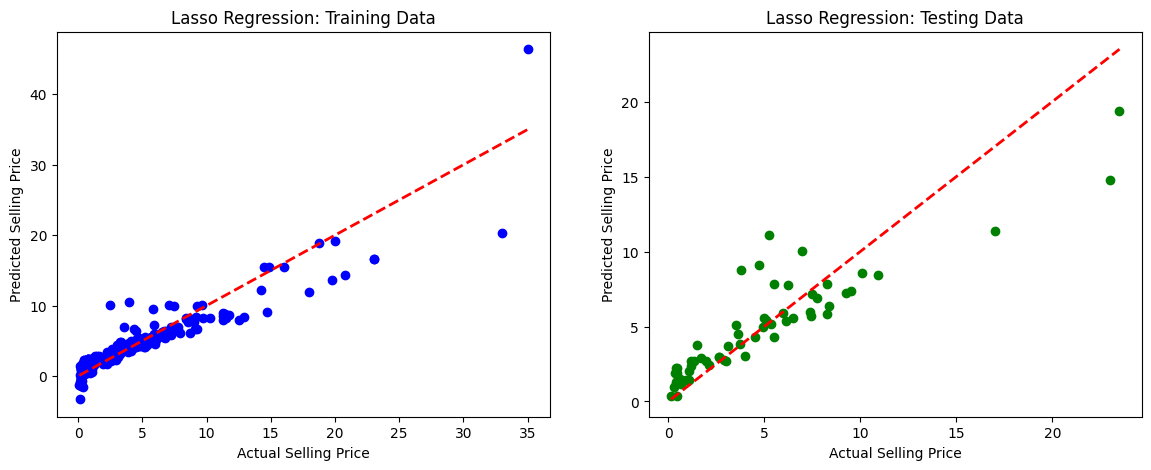

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_train, lasso_model.predict(X_train), color='blue', label='Training Data')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Selling Price')
axes[0].set_ylabel('Predicted Selling Price')
axes[0].set_title('Lasso Regression: Training Data')

axes[1].scatter(y_test, lasso_model.predict(X_test), color='green', label='Testing Data')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Selling Price')
axes[1].set_ylabel('Predicted Selling Price')
axes[1].set_title('Lasso Regression: Testing Data')
plt.show()

In [23]:
# Model 3: Random Forest

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest")
print("\nTraining Data")
print("R2 Score:", r2_score(y_train, rf_model.predict(X_train)))
print("Mean Absolute Error:", mean_absolute_error(y_train, rf_model.predict(X_train)))
print("Mean Squared Error:", mean_squared_error(y_train, rf_model.predict(X_train)))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_train, rf_model.predict(X_train))))

print("\nTesting Data")
print("R2 Score:", r2_score(y_test, rf_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, rf_pred))
print("Mean Squared Error:", mean_squared_error(y_test, rf_pred))
print("Root Mean Squared Error:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest

Training Data
R2 Score: 0.9840655518448314
Mean Absolute Error: 0.2623804166666664
Mean Squared Error: 0.42125991145833325
Root Mean Squared Error: 0.6490453847446519

Testing Data
R2 Score: 0.9625164143622483
Mean Absolute Error: 0.620155737704918
Mean Squared Error: 0.8634563050819668
Root Mean Squared Error: 0.9292234957651291


In [24]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

         Feature  Importance
1  Present_Price    0.879164
0           Year    0.063727
2     Kms_Driven    0.034059
5   Transmission    0.013077
3      Fuel_Type    0.006480
4    Seller_Type    0.002461
6          Owner    0.001032


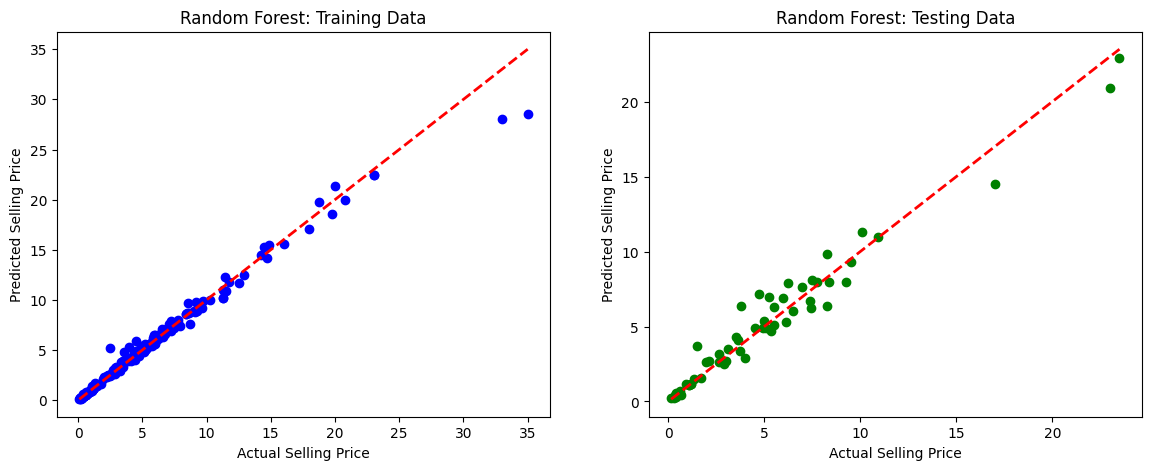

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_train, rf_model.predict(X_train), color='blue', label='Training Data')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', linewidth=2)
axes[0].set_xlabel('Actual Selling Price')
axes[0].set_ylabel('Predicted Selling Price')
axes[0].set_title('Random Forest: Training Data')

axes[1].scatter(y_test, rf_model.predict(X_test), color='green', label='Testing Data')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Selling Price')
axes[1].set_ylabel('Predicted Selling Price')
axes[1].set_title('Random Forest: Testing Data')
plt.show()

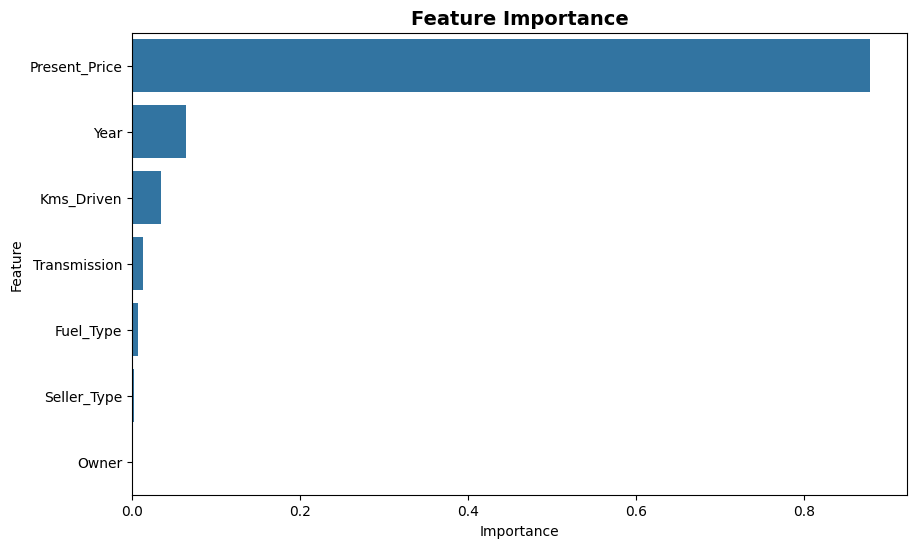

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance['Importance'], y=feature_importance['Feature'])
plt.title('Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()